In [23]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [24]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [25]:
NUM_CLASSES = 27

# Dataset reading

In [26]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [27]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [29]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [30]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_2 (Dropout)         (None, 42)                0         
                                                                 
 dense_3 (Dense)             (None, 20)                860       
                                                                 
 dropout_3 (Dropout)         (None, 20)                0         
                                                                 
 dense_4 (Dense)             (None, 10)                210       
                                                                 
 dense_5 (Dense)             (None, 27)                297       
                                                                 
Total params: 1,367
Trainable params: 1,367
Non-trainable params: 0
_________________________________________________________________


In [31]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [32]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [33]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
 1/11 [=>............................] - ETA: 1s - loss: 3.3899 - accuracy: 0.0703
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
11/11 [==============================] - 0s 9ms/step - loss: 3.3485 - accuracy: 0.0732 - val_loss: 3.2793 - val_accuracy: 0.1419
Epoch 2/1000
 1/11 [=>............................] - ETA: 0s - loss: 3.2817 - accuracy: 0.0781
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
11/11 [==============================] - 0s 2ms/step - loss: 3.2667 - accuracy: 0.0940 - val_loss: 3.2143 - val_accuracy: 0.2086
Epoch 3/1000
 1/11 [=>............................] - ETA: 0s - loss: 3.2172 - accuracy: 0.0938
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
11/11 [==============================] - 0s 2ms/step - loss: 3.1931 - accuracy: 0.1184 - val_loss: 3.1395 - val_accuracy: 0.1871
Epoch 4/1000
 1/11 [=>............................] - ETA: 0s - loss: 3.1501 - accuracy: 0.1797
E

In [34]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

4/4 [==============================] - 0s 601us/step - loss: 0.2000 - accuracy: 0.9763


In [35]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [36]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 26ms/step
[1.04358317e-02 5.08330166e-01 1.64568643e-04 1.13749025e-04
 6.26973982e-04 4.09860671e-01 6.91177323e-02 1.16928334e-08
 8.93439989e-08 6.97317981e-09 2.26577477e-08 2.34655229e-08
 2.53001318e-08 7.24758609e-09 7.68373143e-10 2.73287935e-08
 1.81964310e-08 3.18503690e-09 1.10741425e-08 2.23981678e-09
 1.54973656e-09 1.34987792e-03 4.42167618e-08 1.71714785e-08
 1.78934219e-08 8.35138110e-08 4.66920280e-09]
1


# Confusion matrix

15/15 [==============================] - 0s 378us/step


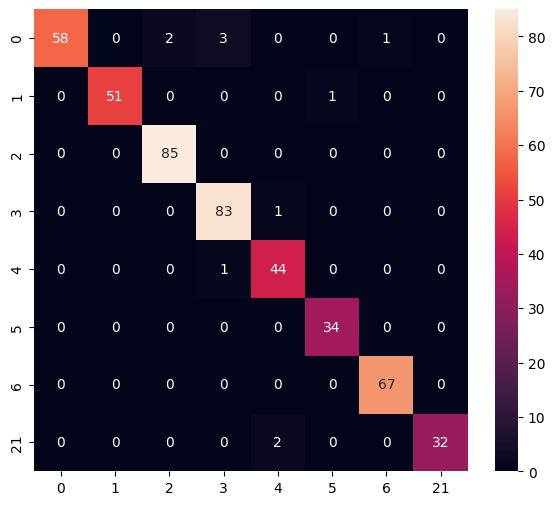

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        64
           1       1.00      0.98      0.99        52
           2       0.98      1.00      0.99        85
           3       0.95      0.99      0.97        84
           4       0.94      0.98      0.96        45
           5       0.97      1.00      0.99        34
           6       0.99      1.00      0.99        67
          21       1.00      0.94      0.97        34

    accuracy                           0.98       465
   macro avg       0.98      0.97      0.98       465
weighted avg       0.98      0.98      0.98       465



In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [38]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [39]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpnk1ngj6z/assets


INFO:tensorflow:Assets written to: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpnk1ngj6z/assets
2022-12-12 21:17:47.149717: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2022-12-12 21:17:47.149730: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2022-12-12 21:17:47.149807: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpnk1ngj6z
2022-12-12 21:17:47.150585: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2022-12-12 21:17:47.150591: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpnk1ngj6z
2022-12-12 21:17:47.153214: I tensorflow/cc/saved_model/loader.cc:229] Restoring SavedModel bundle.
2022-12-12 21:17:47.177950: I tensorflow/cc/saved_model/loader.cc:213] Running initialization

7584

# Inference test

In [40]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [41]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [42]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [43]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 21 µs, sys: 4 µs, total: 25 µs
Wall time: 26.2 µs


In [44]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.04358187e-02 5.08330643e-01 1.64567857e-04 1.13748807e-04
 6.26973109e-04 4.09860462e-01 6.91175833e-02 1.16928005e-08
 8.93437431e-08 6.97315983e-09 2.26576820e-08 2.34654109e-08
 2.53000572e-08 7.24755145e-09 7.68369424e-10 2.73287153e-08
 1.81963777e-08 3.18502158e-09 1.10741105e-08 2.23980590e-09
 1.54973212e-09 1.34987338e-03 4.42166339e-08 1.71714269e-08
 1.78933703e-08 8.35135694e-08 4.66918060e-09]
1
